# Graph cho hướng nghiên cứu MLC-PA + ECC

Notebook này dùng cho các dataset đa nhãn dạng `.arff` / `.xml` của nhóm:
- `emotions`
- `medical`
- `Yeast`
- `Scene`

Mục tiêu:
1. Đọc dữ liệu multi-label.
2. Tách tập đặc trưng `X` và tập nhãn `Y`.
3. Tính thống kê dữ liệu.
4. Vẽ các graph phục vụ hướng nghiên cứu **MLC-PA + ECC**:
   - Dataset Statistics
   - Label Frequency Distribution
   - Label Cardinality Distribution
   - Label Density
   - Label Correlation Heatmap
   - Pairwise Association Matrix
   - Label Co-occurrence Network
   - Top Pairwise Label Associations
5. Xuất toàn bộ hình vào thư mục `outputs/graphs`.


In [36]:
import os
import re
import math
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

## 1. Khai báo đường dẫn dữ liệu


In [27]:
LOCAL_DATA_DIR = Path("./data")
SANDBOX_DATA_DIR = Path("/mnt/data")

DATA_DIR = LOCAL_DATA_DIR if LOCAL_DATA_DIR.exists() else SANDBOX_DATA_DIR
OUTPUT_DIR = Path("./outputs/graphs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    "emotions": {
        "arff": DATA_DIR / "emotions.arff",
        "xml": DATA_DIR / "emotions.xml",
        "note": "Music emotion multi-label dataset"
    },
    "medical": {
        "arff": DATA_DIR / "medical.arff",
        "xml": DATA_DIR / "medical.xml",
        "note": "Medical text multi-label dataset"
    },
    "Yeast": {
        "arff": DATA_DIR / "Yeast.arff",
        "xml": None,
        "note": "Biological protein function multi-label dataset"
    },
    "Scene": {
        "arff": DATA_DIR / "Scene.arff",
        "xml": DATA_DIR / "Scene.xml" if (DATA_DIR / "Scene.xml").exists() else None,
        "note": "Image scene multi-label dataset"
    },
}

for name, cfg in DATASETS.items():
    print(name, "ARFF exists:", cfg["arff"].exists(), "| XML:", cfg["xml"])


emotions ARFF exists: True | XML: data\emotions.xml
medical ARFF exists: True | XML: data\medical.xml
Yeast ARFF exists: True | XML: None
Scene ARFF exists: True | XML: None


## 2. Hàm đọc ARFF/XML

Một số file ARFF multi-label dùng dạng dense, một số dùng sparse format `{index value, index value, ...}`. Parser dưới đây đọc được cả hai dạng.


In [28]:
def parse_xml_labels(xml_path):
    """Đọc danh sách nhãn từ file XML theo chuẩn Mulan."""
    if xml_path is None or not Path(xml_path).exists():
        return None

    root = ET.parse(xml_path).getroot()
    labels = []
    for elem in root.iter():
        if elem.tag.endswith("label") and "name" in elem.attrib:
            labels.append(elem.attrib["name"])
    return labels


def parse_arff_header(arff_path):
    """Đọc phần header của file ARFF để lấy relation và danh sách attributes."""
    relation = None
    attributes = []

    with open(arff_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("%"):
                continue

            low = s.lower()

            if low.startswith("@relation"):
                parts = s.split(None, 1)
                relation = parts[1] if len(parts) > 1 else ""

            elif low.startswith("@attribute"):
                rest = s[len("@attribute"):].strip()

                if rest and rest[0] in ["'", '"']:
                    q = rest[0]
                    end = rest.find(q, 1)
                    name = rest[1:end]
                    attr_type = rest[end+1:].strip()
                else:
                    parts = rest.split(None, 1)
                    name = parts[0]
                    attr_type = parts[1] if len(parts) > 1 else ""

                attributes.append((name, attr_type))

            elif low.startswith("@data"):
                break

    return relation, attributes


def load_arff_to_dataframe(arff_path):
    """Đọc ARFF thành pandas DataFrame, hỗ trợ dense và sparse format."""
    relation, attributes = parse_arff_header(arff_path)
    attr_names = [a[0] for a in attributes]

    rows = []
    in_data = False

    with open(arff_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("%"):
                continue

            if not in_data:
                if s.lower().startswith("@data"):
                    in_data = True
                continue

            if s.startswith("{") and s.endswith("}"):
                values = [0] * len(attr_names)
                inside = s[1:-1].strip()

                if inside:
                    for part in re.split(r",\s*", inside):
                        if not part:
                            continue
                        idx_val = part.strip().split(None, 1)
                        if len(idx_val) == 2:
                            idx = int(idx_val[0])
                            val = idx_val[1].strip().strip("'\"")
                            try:
                                val = float(val)
                            except ValueError:
                                pass
                            values[idx] = val

                rows.append(values)

            else:
                parts = [x.strip().strip("'\"") for x in s.split(",")]
                values = []
                for val in parts:
                    try:
                        values.append(float(val))
                    except ValueError:
                        values.append(val)
                rows.append(values)

    return pd.DataFrame(rows, columns=attr_names)


def infer_label_columns(arff_path, xml_path=None):
    """
    Suy luận cột nhãn:
    1. Nếu có XML: lấy nhãn từ XML.
    2. Nếu relation có '-C k': lấy k cột đầu theo chuẩn một số bộ Mulan như Yeast.
    3. Fallback: lấy các cột nhị phân nominal.
    """
    relation, attributes = parse_arff_header(arff_path)
    attr_names = [a[0] for a in attributes]

    xml_labels = parse_xml_labels(xml_path)
    if xml_labels:
        label_cols = [c for c in attr_names if c in xml_labels]
        if len(label_cols) == len(xml_labels):
            feature_cols = [c for c in attr_names if c not in set(label_cols)]
            return feature_cols, label_cols

    m = re.search(r"-C\s+(\d+)", relation or "")
    if m:
        k = int(m.group(1))
        label_cols = attr_names[:k]
        feature_cols = attr_names[k:]
        return feature_cols, label_cols

    binary_cols = []
    for name, attr_type in attributes:
        if re.search(r"\{\s*0\s*,\s*1\s*\}|\{\s*1\s*,\s*0\s*\}", attr_type):
            binary_cols.append(name)

    label_cols = binary_cols
    feature_cols = [c for c in attr_names if c not in set(label_cols)]
    return feature_cols, label_cols


def load_multilabel_dataset(name, cfg):
    df = load_arff_to_dataframe(cfg["arff"])
    feature_cols, label_cols = infer_label_columns(cfg["arff"], cfg.get("xml"))

    X = df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
    Y = df[label_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

    return df, X, Y, feature_cols, label_cols


## 3. Load toàn bộ dataset và xem thống kê cơ bản


In [29]:
loaded = {}

for name, cfg in DATASETS.items():
    df, X, Y, feature_cols, label_cols = load_multilabel_dataset(name, cfg)
    loaded[name] = {
        "df": df,
        "X": X,
        "Y": Y,
        "feature_cols": feature_cols,
        "label_cols": label_cols
    }

    print("=" * 80)
    print("Dataset:", name)
    print("Shape:", df.shape)
    print("Instances:", len(df))
    print("Features:", len(feature_cols))
    print("Labels:", len(label_cols))
    print("First labels:", label_cols[:10])
    print("Label cardinality:", round(Y.sum(axis=1).mean(), 4))
    print("Label density:", round(Y.sum(axis=1).mean() / len(label_cols), 4))


Dataset: emotions
Shape: (593, 78)
Instances: 593
Features: 72
Labels: 6
First labels: ['amazed-suprised', 'happy-pleased', 'relaxing-calm', 'quiet-still', 'sad-lonely', 'angry-aggresive']
Label cardinality: 1.8685
Label density: 0.3114
Dataset: medical
Shape: (978, 1494)
Instances: 978
Features: 1449
Labels: 45
First labels: ['Class-0-593_70', 'Class-1-079_99', 'Class-2-786_09', 'Class-3-759_89', 'Class-4-753_0', 'Class-5-786_2', 'Class-6-V72_5', 'Class-7-511_9', 'Class-8-596_8', 'Class-9-599_0']
Label cardinality: 1.2454
Label density: 0.0277
Dataset: Yeast
Shape: (2417, 117)
Instances: 2417
Features: 103
Labels: 14
First labels: ['Class1', 'Class2', 'Class3', 'Class4', 'Class5', 'Class6', 'Class7', 'Class8', 'Class9', 'Class10']
Label cardinality: 4.2371
Label density: 0.3026
Dataset: Scene
Shape: (2407, 300)
Instances: 2407
Features: 294
Labels: 6
First labels: ['beach', 'sunset', 'foliage', 'field', 'mountain', 'urban']
Label cardinality: 1.074
Label density: 0.179


## 4. Bảng Dataset Statistics


In [30]:
summary_rows = []

for name, obj in loaded.items():
    Y = obj["Y"]
    summary_rows.append({
        "Dataset": name,
        "Instances": Y.shape[0],
        "Features": len(obj["feature_cols"]),
        "Labels": Y.shape[1],
        "Label Cardinality": Y.sum(axis=1).mean(),
        "Label Density": Y.sum(axis=1).mean() / Y.shape[1],
        "Distinct Labelsets": Y.drop_duplicates().shape[0]
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Dataset,Instances,Features,Labels,Label Cardinality,Label Density,Distinct Labelsets
0,emotions,593,72,6,1.868465,0.311411,27
1,medical,978,1449,45,1.245399,0.027676,94
2,Yeast,2417,103,14,4.237071,0.302648,198
3,Scene,2407,294,6,1.073951,0.178992,15


In [31]:
summary_df.to_csv(OUTPUT_DIR / "dataset_statistics.csv", index=False)
print("Saved:", OUTPUT_DIR / "dataset_statistics.csv")


Saved: outputs\graphs\dataset_statistics.csv


## 5. Graph 1 — Dataset Statistics


Graph này tóm tắt cấu trúc dataset theo số lượng mẫu, số lượng thuộc tính và số lượng nhãn. 
Mục đích là so sánh nhanh các dataset trước khi đi vào phân tích đa nhãn sâu hơn.

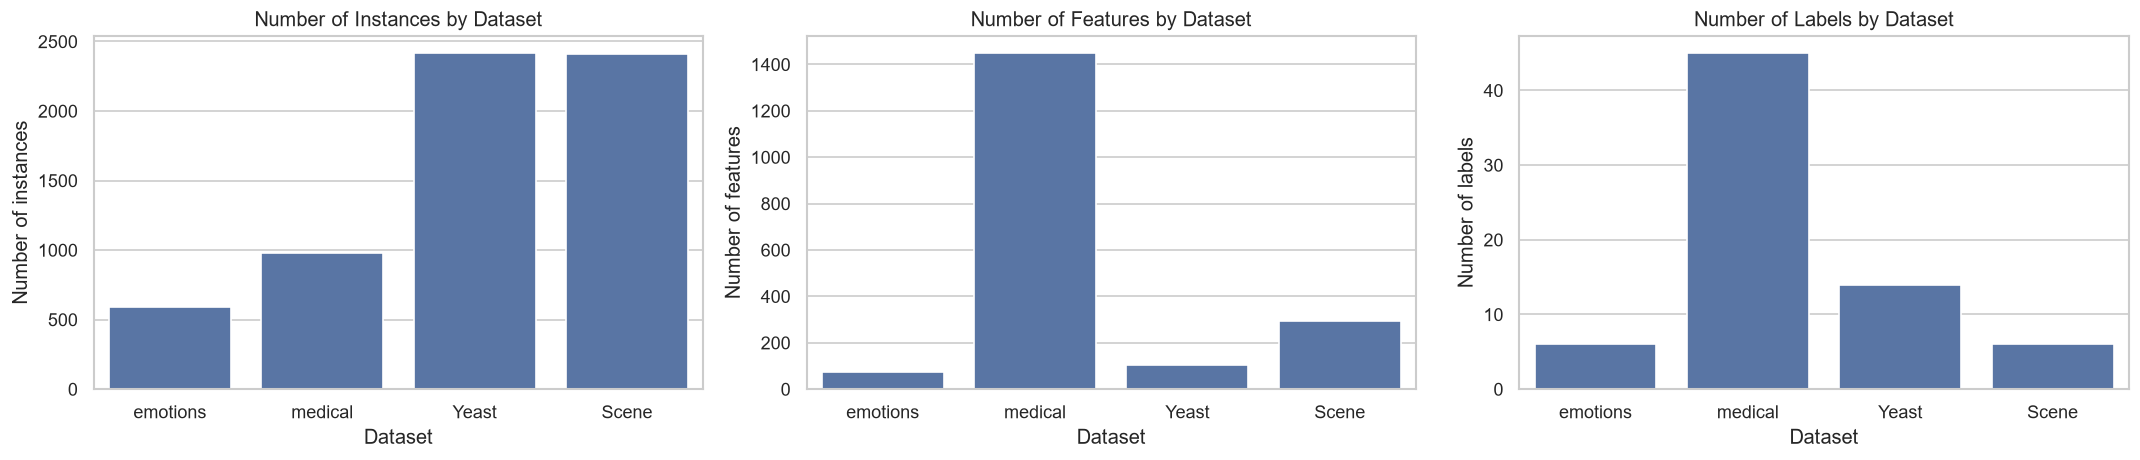

Saved: outputs\graphs\01_dataset_summary.pdf


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.barplot(data=summary_df, x="Dataset", y="Instances", ax=axes[0])
axes[0].set_title("Number of Instances by Dataset")
axes[0].set_xlabel("Dataset")
axes[0].set_ylabel("Number of instances")

sns.barplot(data=summary_df, x="Dataset", y="Features", ax=axes[1])
axes[1].set_title("Number of Features by Dataset")
axes[1].set_xlabel("Dataset")
axes[1].set_ylabel("Number of features")

sns.barplot(data=summary_df, x="Dataset", y="Labels", ax=axes[2])
axes[2].set_title("Number of Labels by Dataset")
axes[2].set_xlabel("Dataset")
axes[2].set_ylabel("Number of labels")

plt.tight_layout()
path = OUTPUT_DIR / "01_dataset_summary.pdf"
plt.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)

## 6. Graph 2 — Label Frequency Distribution

Graph này hiển thị tần suất mỗi nhãn xuất hiện trong dataset. 
Mục đích là kiểm tra **label imbalance** và xác định nhãn hiếm để lựa chọn chiến lược học phù hợp.


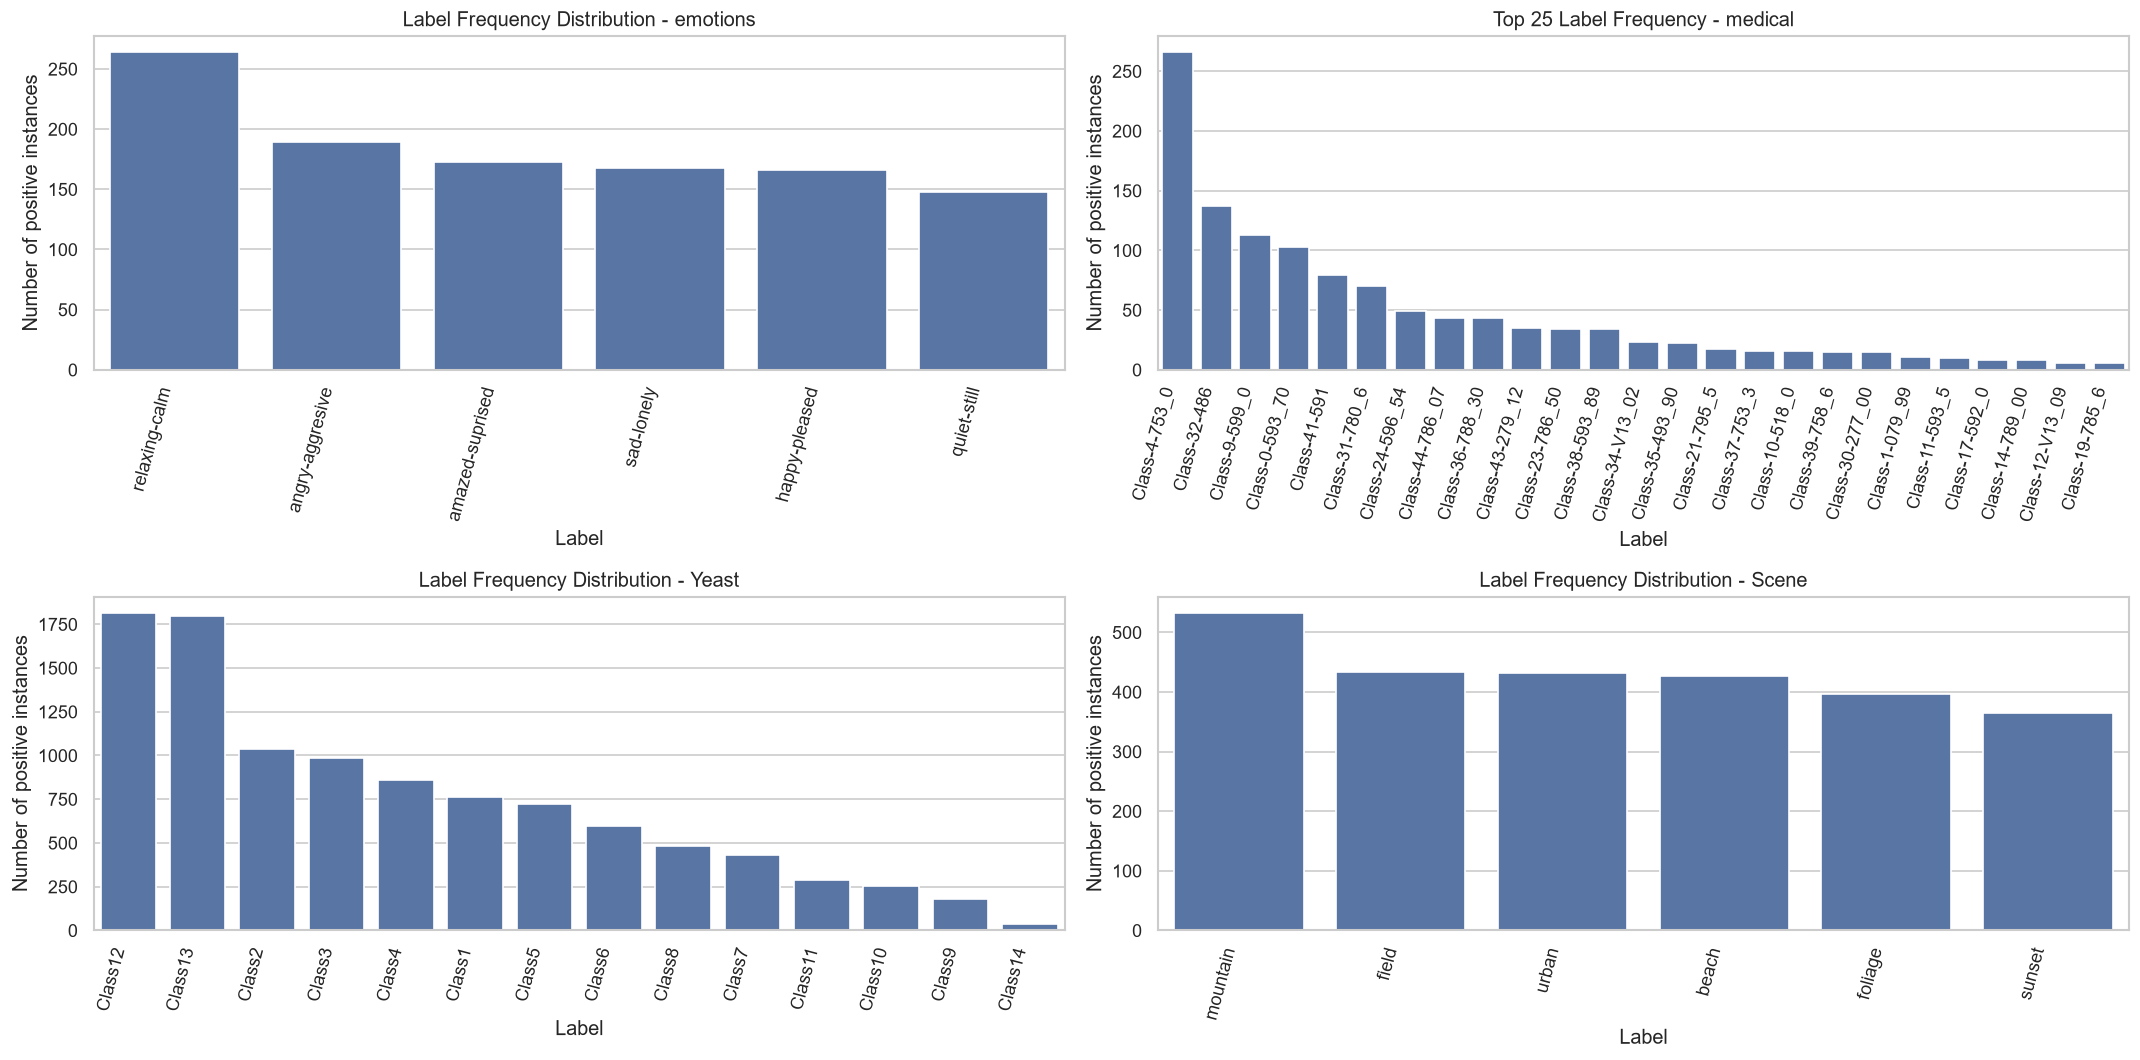

Saved: outputs\graphs\02_label_frequency_all.pdf


In [33]:
import math

def plot_label_frequency(ax, dataset_name, Y, top_k=None):
    freq = Y.sum(axis=0).sort_values(ascending=False)

    if top_k is not None:
        freq_plot = freq.head(top_k)
        title = f"Top {top_k} Label Frequency - {dataset_name}"
    else:
        freq_plot = freq
        title = f"Label Frequency Distribution - {dataset_name}"

    sns.barplot(x=freq_plot.index, y=freq_plot.values, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Label")
    ax.set_ylabel("Number of positive instances")
    ax.tick_params(axis="x", rotation=75)
    for label in ax.get_xticklabels():
        label.set_ha("right")

    return freq


label_frequency_tables = {}
n = len(loaded)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 4.5 * nrows))
axes = axes.flatten() if n > 1 else [axes]

for ax, (name, obj) in zip(axes, loaded.items()):
    Y = obj["Y"]
    top_k = 25 if Y.shape[1] > 25 else None
    freq = plot_label_frequency(ax, name, Y, top_k=top_k)
    label_frequency_tables[name] = freq
    freq.to_csv(OUTPUT_DIR / f"02_label_frequency_{name}.csv")

# Ẩn các ô trống nếu số dataset lẻ (không chia hết cho ncols)
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
path = OUTPUT_DIR / "02_label_frequency_all.pdf"
plt.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)


## 7. Graph 3 — Label Cardinality Distribution

Graph này biểu diễn phân phối số nhãn trên mỗi mẫu để đánh giá mức độ đa nhãn của dataset.
Mục đích là hiểu liệu phần lớn mẫu có nhiều nhãn hay chỉ một vài nhãn, điều này ảnh hưởng đến mô hình hóa đa nhãn.

\[

LC = \frac{1}{N}\sum_{i=1}^{N}|Y_i|
\]

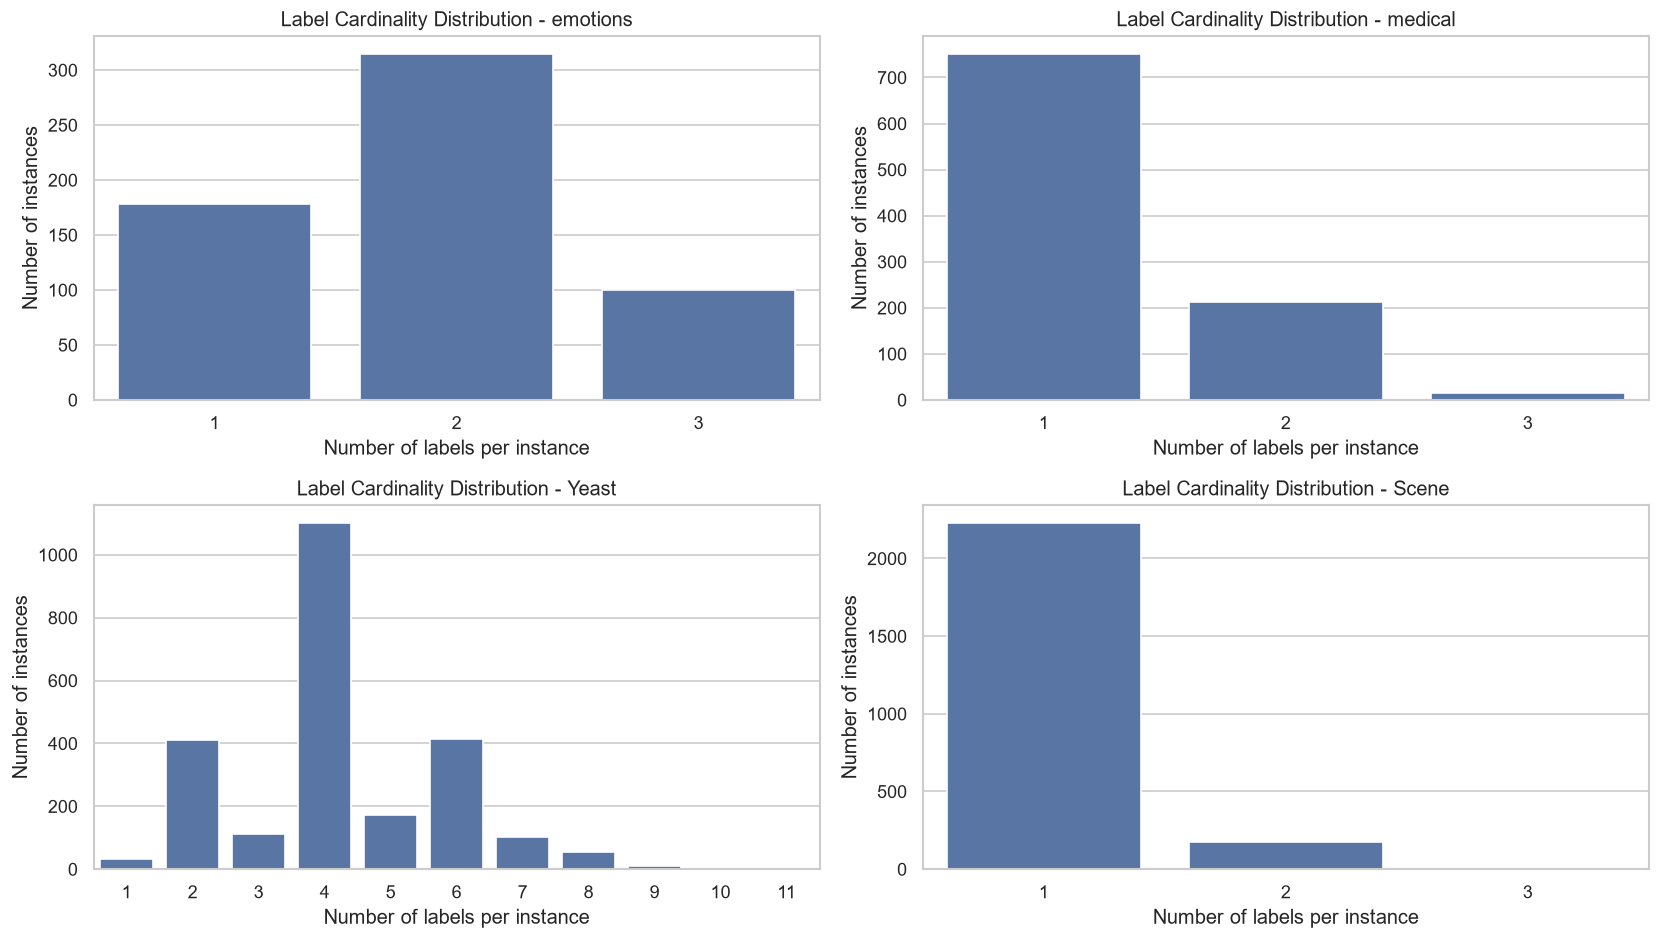

Saved: outputs\graphs\03_label_cardinality_distribution_all.pdf


In [34]:
import math

def plot_label_cardinality_distribution(ax, dataset_name, Y):
    label_count_per_sample = Y.sum(axis=1)
    dist = label_count_per_sample.value_counts().sort_index()

    sns.barplot(x=dist.index.astype(str), y=dist.values, ax=ax)
    ax.set_title(f"Label Cardinality Distribution - {dataset_name}")
    ax.set_xlabel("Number of labels per instance")
    ax.set_ylabel("Number of instances")

    return dist


cardinality_distribution_tables = {}
n = len(loaded)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows))
axes = axes.flatten() if n > 1 else [axes]

for ax, (name, obj) in zip(axes, loaded.items()):
    dist = plot_label_cardinality_distribution(ax, name, obj["Y"])
    cardinality_distribution_tables[name] = dist
    dist.to_csv(OUTPUT_DIR / f"03_label_cardinality_distribution_{name}.csv")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
path = OUTPUT_DIR / "03_label_cardinality_distribution_all.pdf"
plt.savefig(path, bbox_inches="tight")
plt.show()
print("Saved:", path)

## 8. Graph 4 — Label Density Comparison

Graph này so sánh mật độ nhãn của từng dataset, định nghĩa như tỉ lệ nhãn trung bình trên tổng số nhãn.
Mục đích là đánh giá mức độ thưa/đậm nhãn của dataset để chọn phương pháp đa nhãn phù hợp.

\[

LD = \frac{LC}{L}
\]

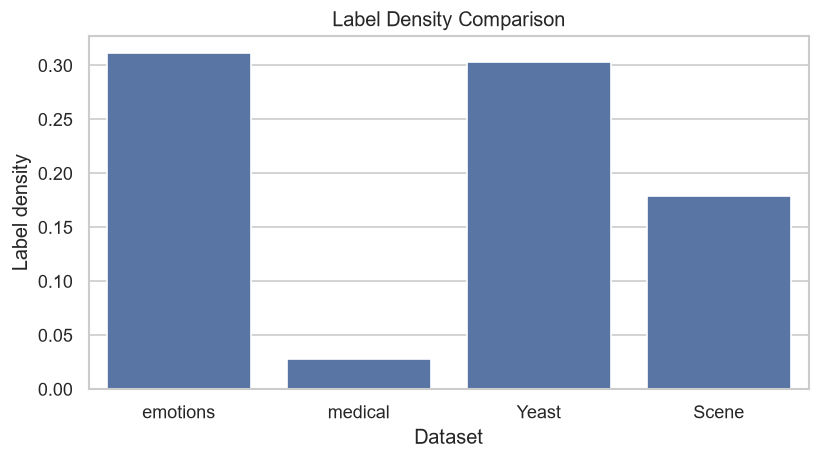

Saved: outputs\graphs\04_label_density_comparison.pdf


In [35]:
plt.figure(figsize=(7, 4))
sns.barplot(data=summary_df, x="Dataset", y="Label Density")
plt.title("Label Density Comparison")
plt.xlabel("Dataset")
plt.ylabel("Label density")
savefig("04_label_density_comparison.pdf")

## 9. Graph 5 — Pairwise Association Matrix

Graph này thể hiện độ liên kết cặp nhãn bằng chỉ số Jaccard, giúp phát hiện các cặp nhãn thường xuất hiện cùng nhau.
Mục đích là cung cấp thông tin cho MLC-PA và ECC khi chọn chuỗi nhãn hoặc thiết kế cấu trúc phụ thuộc.

\[
PA(y_a, y_b) = \frac{|y_a \cap y_b|}{|y_a \cup y_b|}
\]


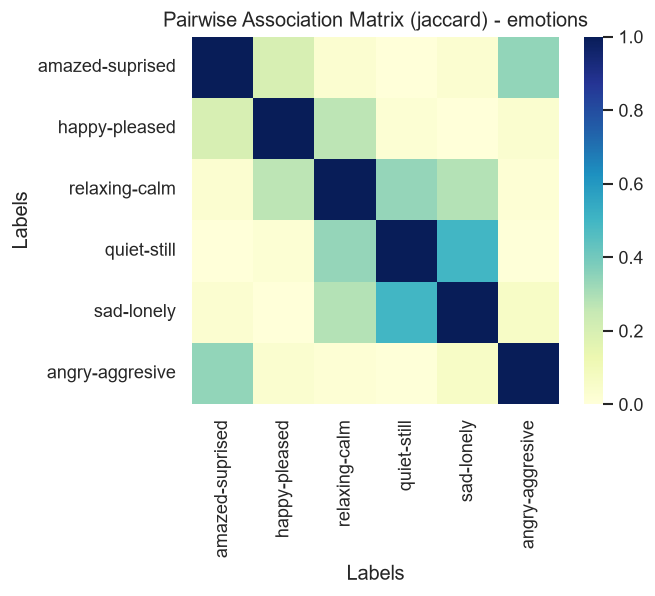

Saved: outputs\graphs\05_pairwise_association_jaccard_emotions.pdf


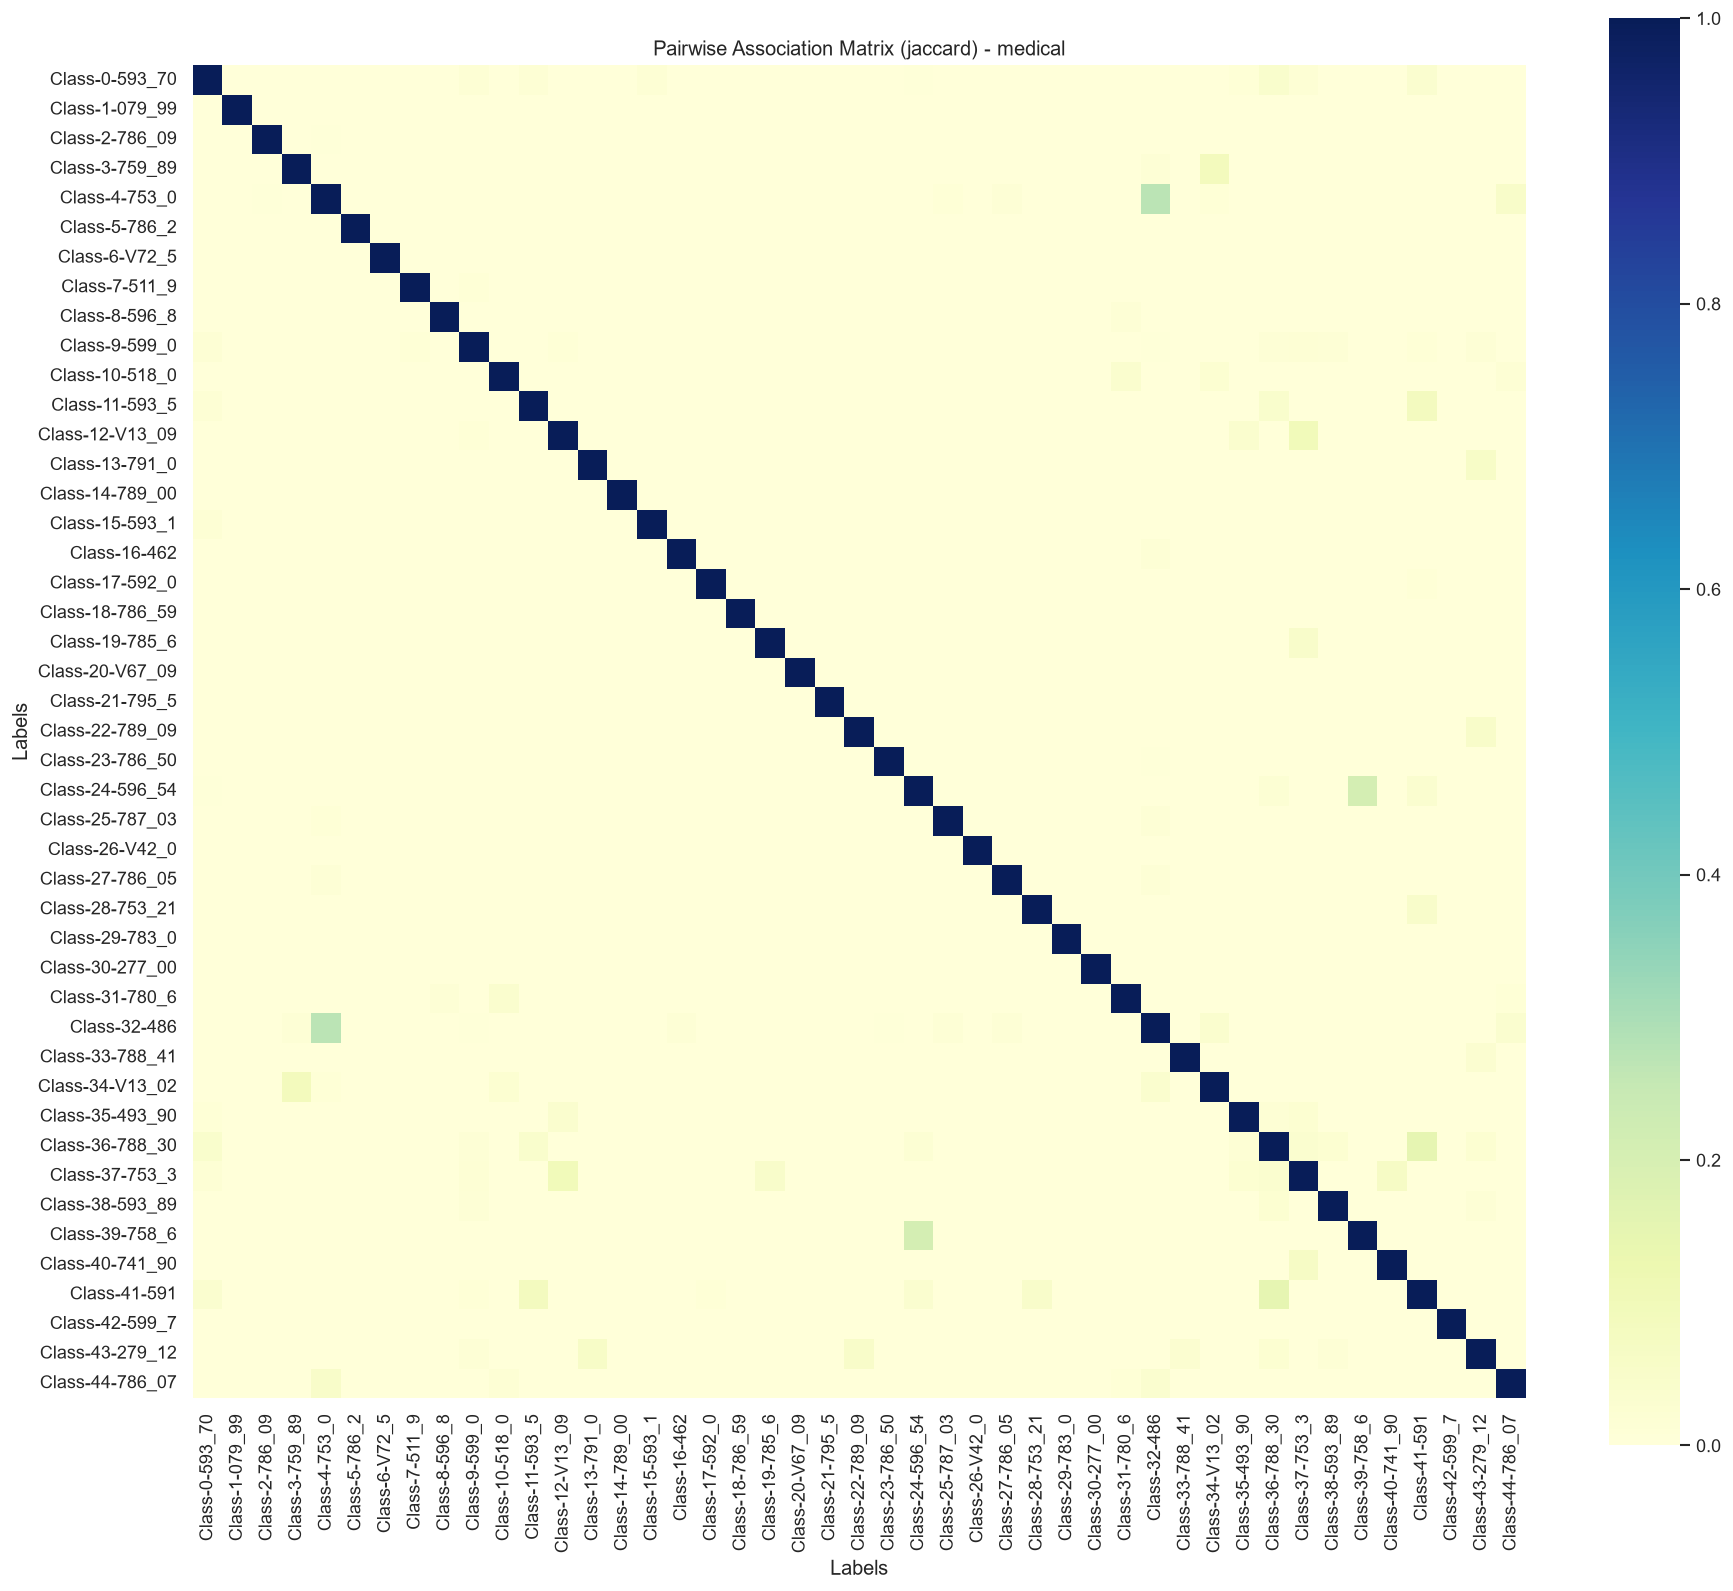

Saved: outputs\graphs\05_pairwise_association_jaccard_medical.pdf


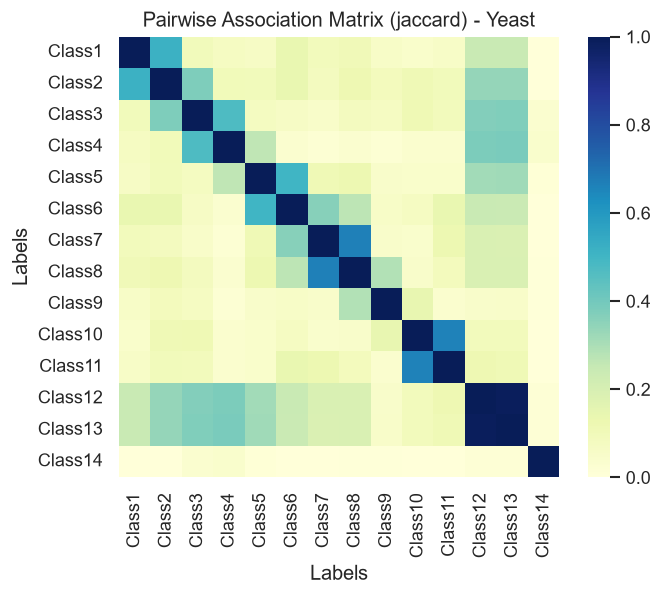

Saved: outputs\graphs\05_pairwise_association_jaccard_Yeast.pdf


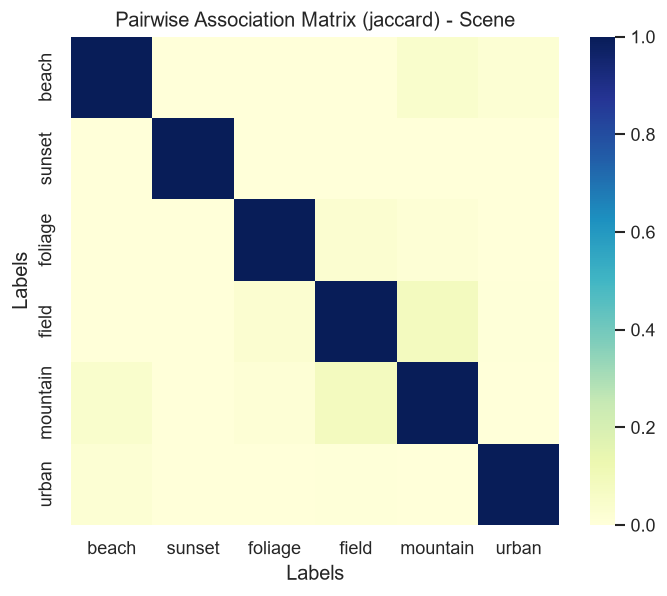

Saved: outputs\graphs\05_pairwise_association_jaccard_Scene.pdf


In [38]:
def compute_pairwise_association(Y, metric="jaccard"):
    labels = list(Y.columns)
    Y_bool = Y.astype(bool)
    pa = pd.DataFrame(np.zeros((len(labels), len(labels))), index=labels, columns=labels)

    for a in labels:
        for b in labels:
            inter = (Y_bool[a] & Y_bool[b]).sum()

            if metric == "jaccard":
                union = (Y_bool[a] | Y_bool[b]).sum()
                value = inter / union if union != 0 else 0

            elif metric == "confidence":
                denom = Y_bool[a].sum()
                value = inter / denom if denom != 0 else 0

            else:
                raise ValueError("metric must be 'jaccard' or 'confidence'")

            pa.loc[a, b] = value

    return pa


def plot_pairwise_association_matrix(dataset_name, Y, metric="jaccard"):
    pa = compute_pairwise_association(Y, metric=metric)

    plt.figure(figsize=(max(6, Y.shape[1] * 0.35), max(5, Y.shape[1] * 0.30)))
    sns.heatmap(pa, cmap="YlGnBu", vmin=0, vmax=1, square=True)
    plt.title(f"Pairwise Association Matrix ({metric}) - {dataset_name}")
    plt.xlabel("Labels")
    plt.ylabel("Labels")
    savefig(f"05_pairwise_association_{metric}_{dataset_name}.pdf")

    pa.to_csv(OUTPUT_DIR / f"05_pairwise_association_{metric}_{dataset_name}.csv")
    return pa


pa_matrices = {}

for name, obj in loaded.items():
    pa_matrices[name] = plot_pairwise_association_matrix(name, obj["Y"], metric="jaccard")


## 10. Graph 6 — Top Pairwise Associations

Graph này giúp dễ phân tích hơn heatmap, nhất là với dataset nhiều nhãn như `medical`.


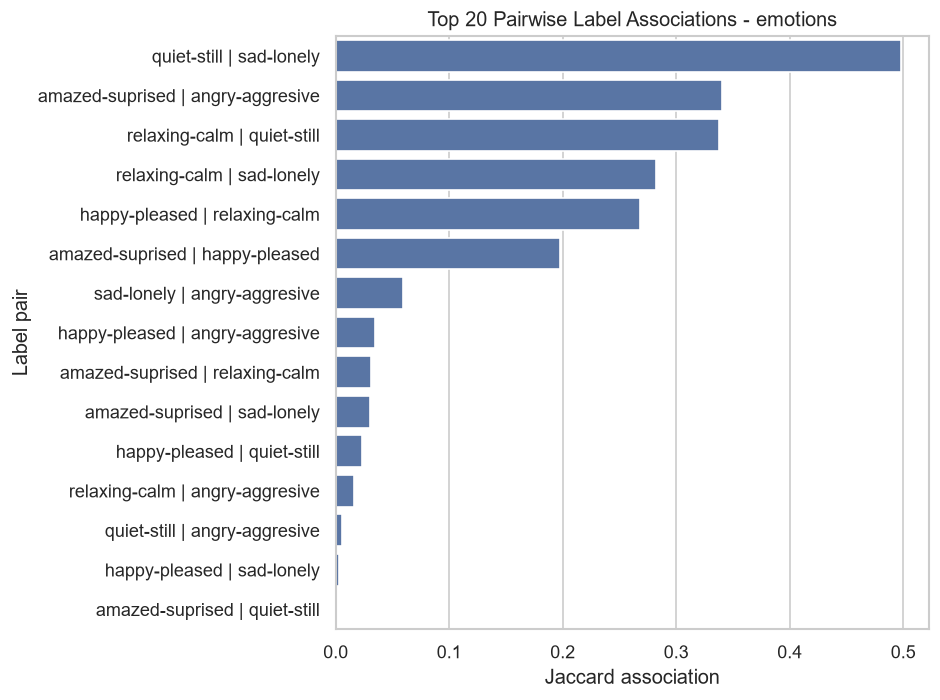

Saved: outputs\graphs\06_top_pairwise_associations_emotions.pdf


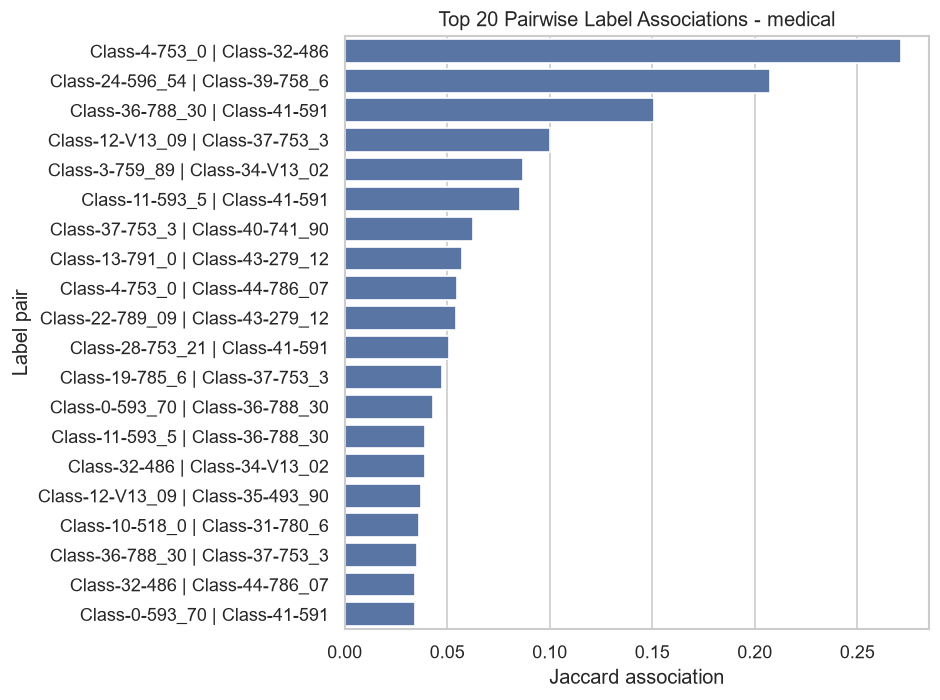

Saved: outputs\graphs\06_top_pairwise_associations_medical.pdf


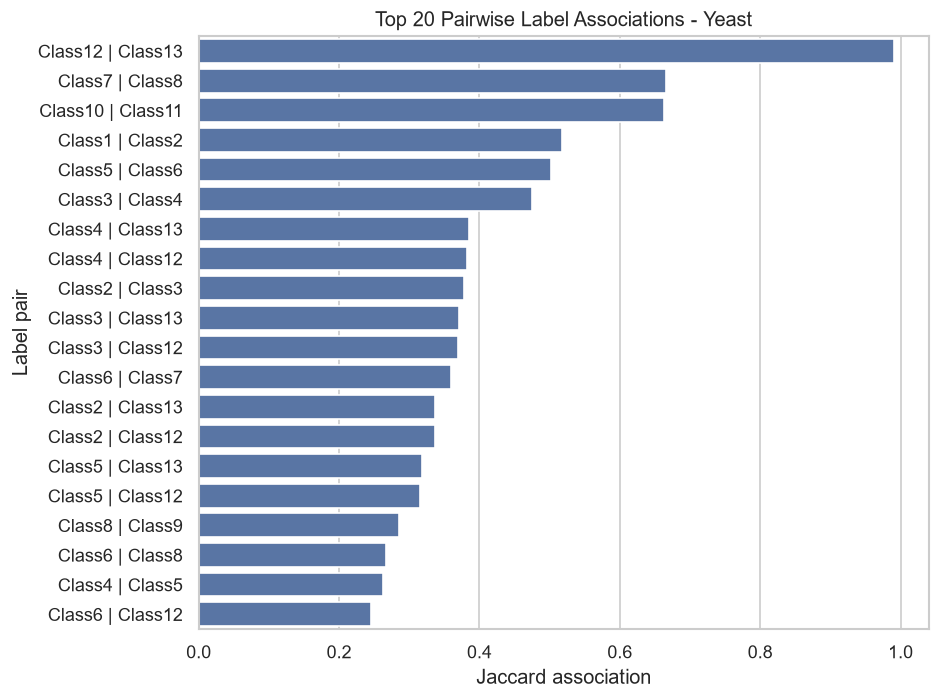

Saved: outputs\graphs\06_top_pairwise_associations_Yeast.pdf


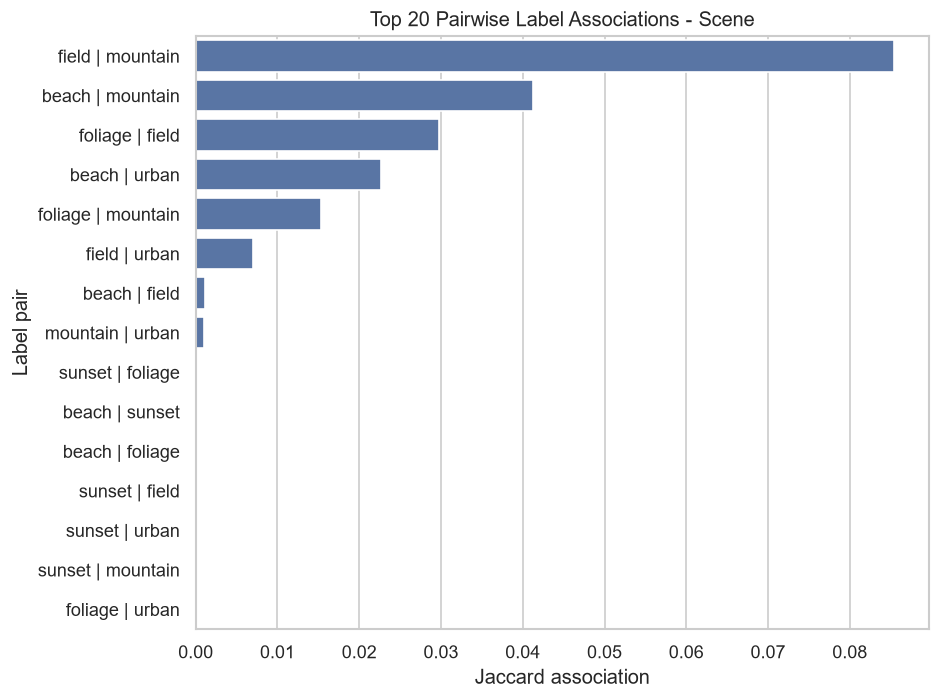

Saved: outputs\graphs\06_top_pairwise_associations_Scene.pdf


In [39]:
def get_top_pairwise_associations(pa_matrix, top_k=20):
    pairs = []
    labels = list(pa_matrix.columns)

    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            a, b = labels[i], labels[j]
            pairs.append({
                "Label Pair": f"{a} | {b}",
                "Label A": a,
                "Label B": b,
                "Association": pa_matrix.loc[a, b]
            })

    pair_df = pd.DataFrame(pairs).sort_values("Association", ascending=False)
    return pair_df.head(top_k)


def plot_top_pairwise_associations(dataset_name, pa_matrix, top_k=20):
    top_pairs = get_top_pairwise_associations(pa_matrix, top_k=top_k)

    plt.figure(figsize=(8, max(4, top_k * 0.3)))
    sns.barplot(data=top_pairs, y="Label Pair", x="Association")
    plt.title(f"Top {top_k} Pairwise Label Associations - {dataset_name}")
    plt.xlabel("Jaccard association")
    plt.ylabel("Label pair")
    savefig(f"06_top_pairwise_associations_{dataset_name}.pdf")

    top_pairs.to_csv(OUTPUT_DIR / f"06_top_pairwise_associations_{dataset_name}.csv", index=False)
    return top_pairs


top_pair_tables = {}

for name, pa in pa_matrices.items():
    top_pair_tables[name] = plot_top_pairwise_associations(name, pa, top_k=20)


## 11. Graph 7 — Label Co-occurrence Network

Graph này trực quan hóa mạng quan hệ giữa nhãn, với node là nhãn và edge là mức độ liên quan.
Mục đích là nhận diện cụm nhãn và kết cấu phụ thuộc trong dữ liệu để hỗ trợ thiết kế ECC.
- Node: nhãn.
- Edge: tồn tại nếu Pairwise Association vượt ngưỡng.

- Edge weight: độ mạnh quan hệ giữa hai nhãn.

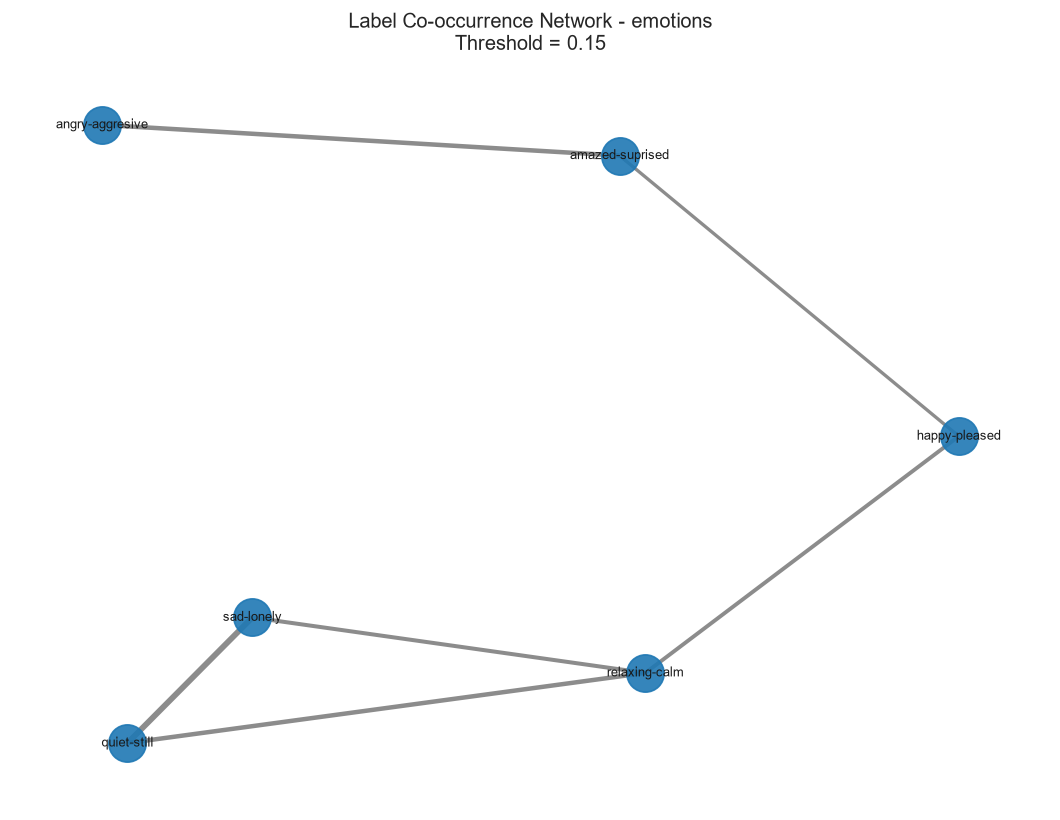

Saved: outputs\graphs\07_label_cooccurrence_network_emotions.pdf
emotions nodes: 6 edges: 6


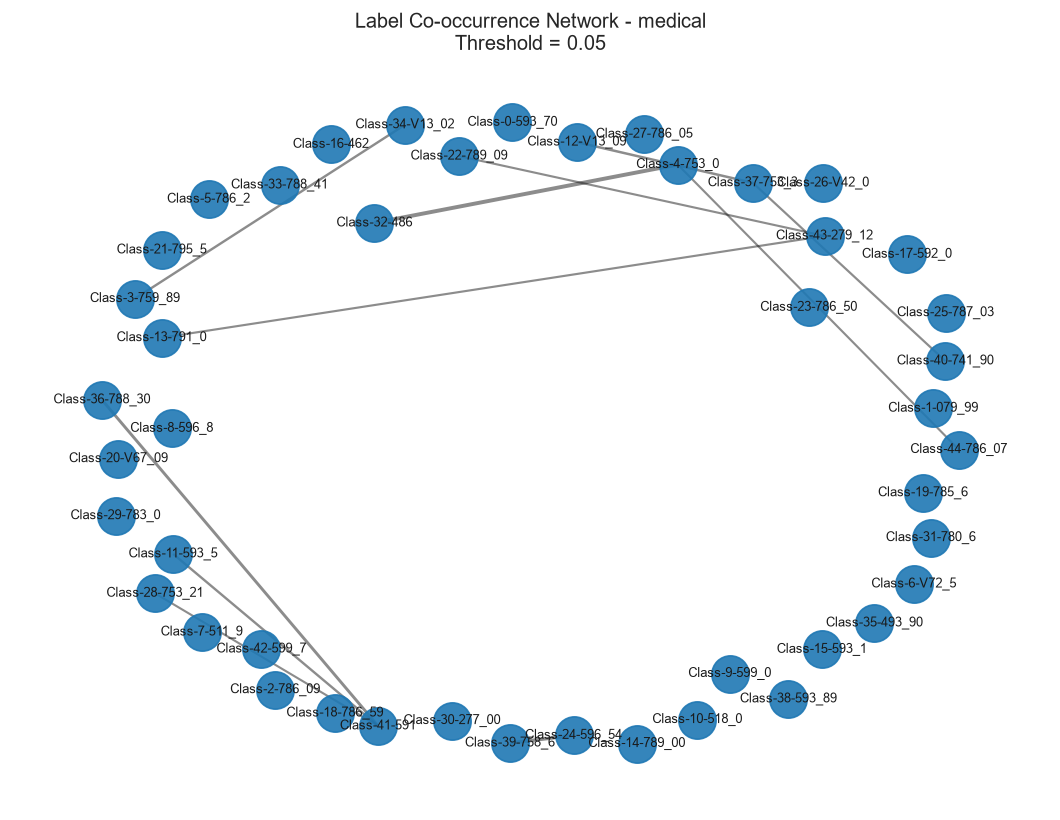

Saved: outputs\graphs\07_label_cooccurrence_network_medical.pdf
medical nodes: 45 edges: 11


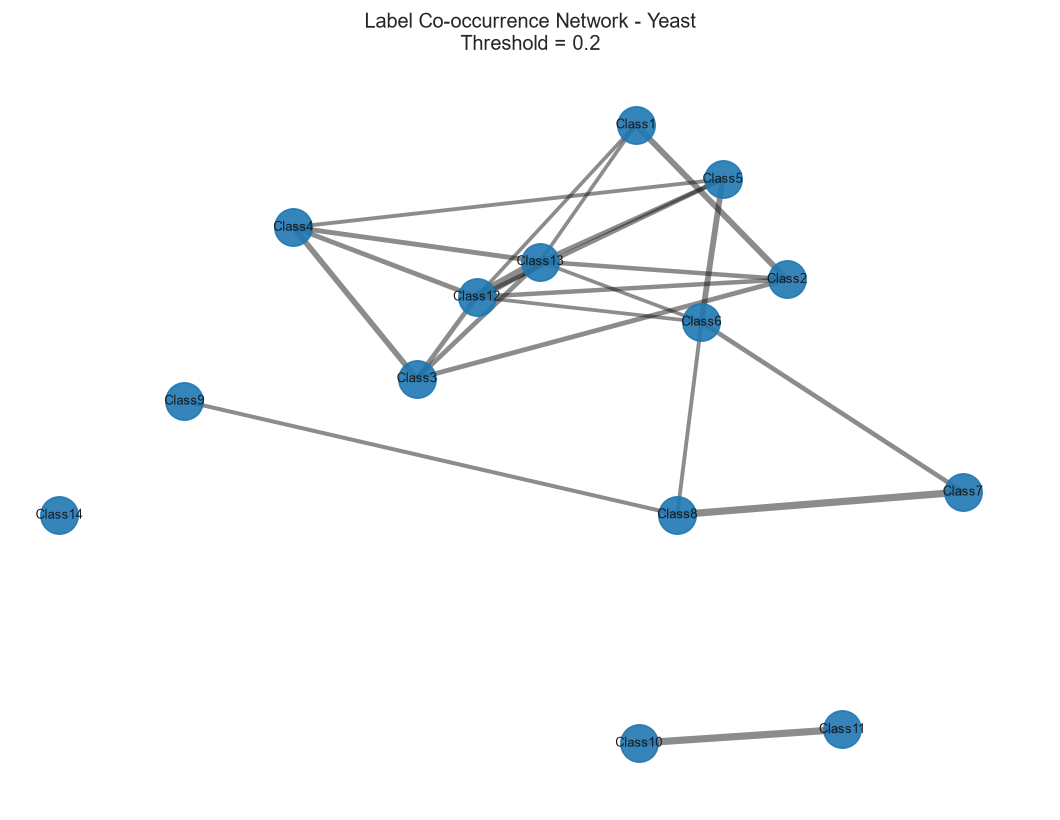

Saved: outputs\graphs\07_label_cooccurrence_network_Yeast.pdf
Yeast nodes: 14 edges: 23


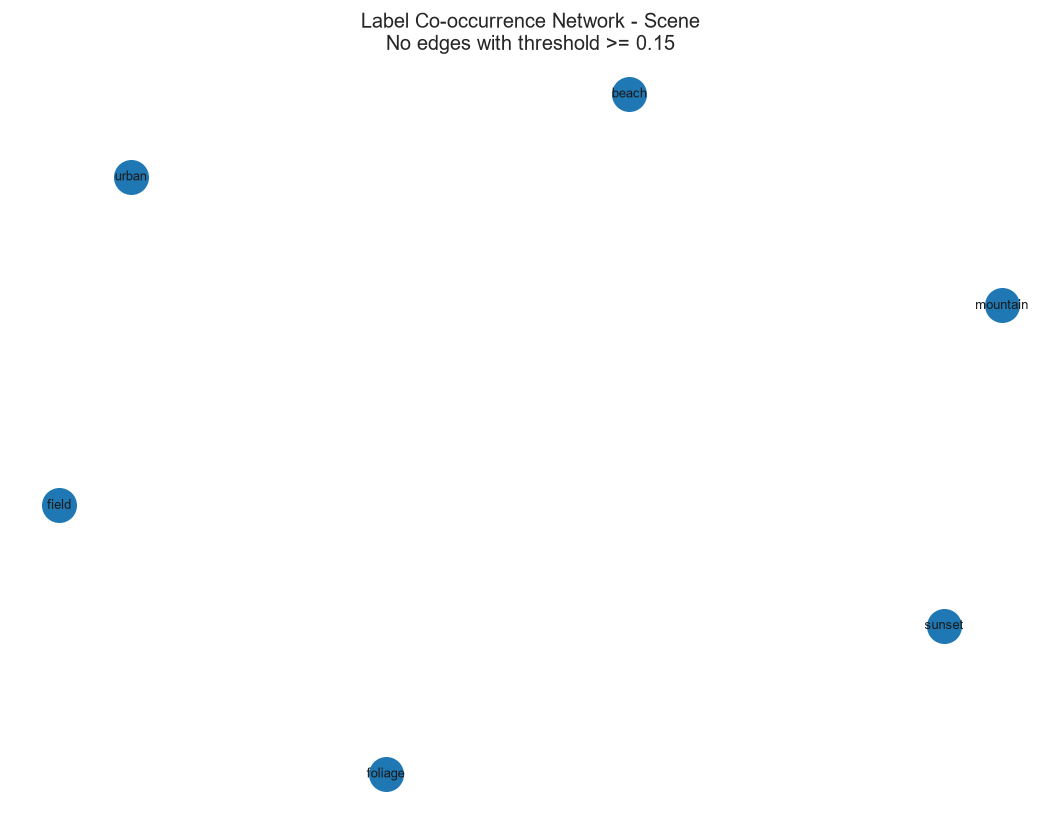

Saved: outputs\graphs\07_label_cooccurrence_network_Scene.pdf
Scene nodes: 6 edges: 0


In [40]:
def plot_label_cooccurrence_network(dataset_name, pa_matrix, threshold=0.15):
    labels = list(pa_matrix.columns)
    G = nx.Graph()

    for label in labels:
        G.add_node(label)

    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            a, b = labels[i], labels[j]
            weight = pa_matrix.loc[a, b]
            if weight >= threshold:
                G.add_edge(a, b, weight=weight)

    plt.figure(figsize=(9, 7))

    pos = nx.spring_layout(G, seed=42, k=0.8)
    if G.number_of_edges() == 0:
        nx.draw_networkx_nodes(G, pos, node_size=400)
        nx.draw_networkx_labels(G, pos, font_size=8)
        plt.title(f"Label Co-occurrence Network - {dataset_name}\nNo edges with threshold >= {threshold}")
    else:
        weights = [G[u][v]["weight"] for u, v in G.edges()]
        widths = [1 + 5 * w for w in weights]
        nx.draw_networkx_nodes(G, pos, node_size=500, alpha=0.9)
        nx.draw_networkx_edges(G, pos, width=widths, alpha=0.5)
        nx.draw_networkx_labels(G, pos, font_size=8)
        plt.title(f"Label Co-occurrence Network - {dataset_name}\nThreshold = {threshold}")

    plt.axis("off")
    savefig(f"07_label_cooccurrence_network_{dataset_name}.pdf")

    edge_df = pd.DataFrame([
        {"Label A": u, "Label B": v, "Association": G[u][v]["weight"]}
        for u, v in G.edges()
    ]).sort_values("Association", ascending=False) if G.number_of_edges() > 0 else pd.DataFrame()

    edge_df.to_csv(OUTPUT_DIR / f"07_label_network_edges_{dataset_name}.csv", index=False)
    return G, edge_df


network_results = {}

threshold_by_dataset = {
    "emotions": 0.15,
    "medical": 0.05,
    "Yeast": 0.20,
}

for name, pa in pa_matrices.items():
    threshold = threshold_by_dataset.get(name, 0.15)
    G, edge_df = plot_label_cooccurrence_network(name, pa, threshold=threshold)
    network_results[name] = {"graph": G, "edges": edge_df}
    print(name, "nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())


## 12. Graph 8 — Feature Space Visualization bằng PCA

Graph này mô tả cấu trúc feature đầu vào trên hai thành phần chính, với màu sắc thể hiện số nhãn mỗi mẫu.
Mục đích là kiểm tra xem các mẫu có phân bố theo số lượng nhãn hay theo cụm đặc trưng, hỗ trợ lựa chọn mô hình và tiền xử lý.

\[
X_{proj} = X W, \quad W \in \mathbb{R}^{d \times 2}
\]

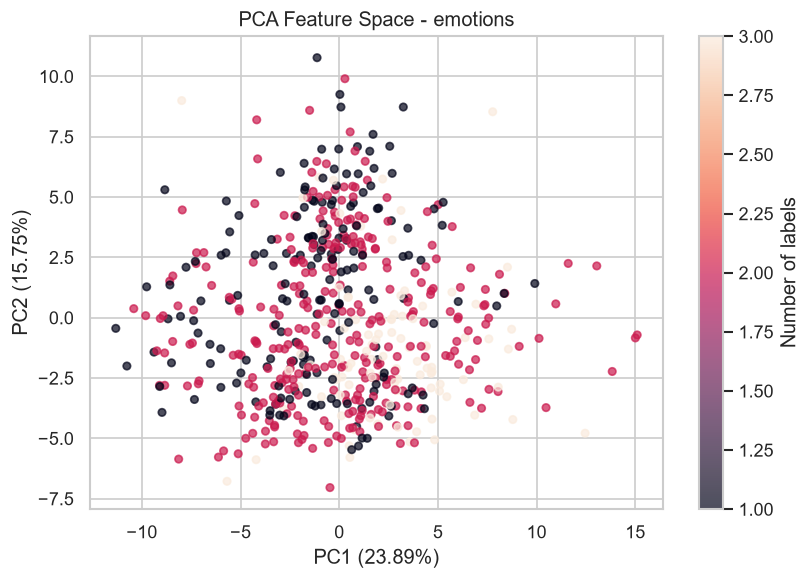

Saved: outputs\graphs\08_pca_feature_space_emotions.pdf


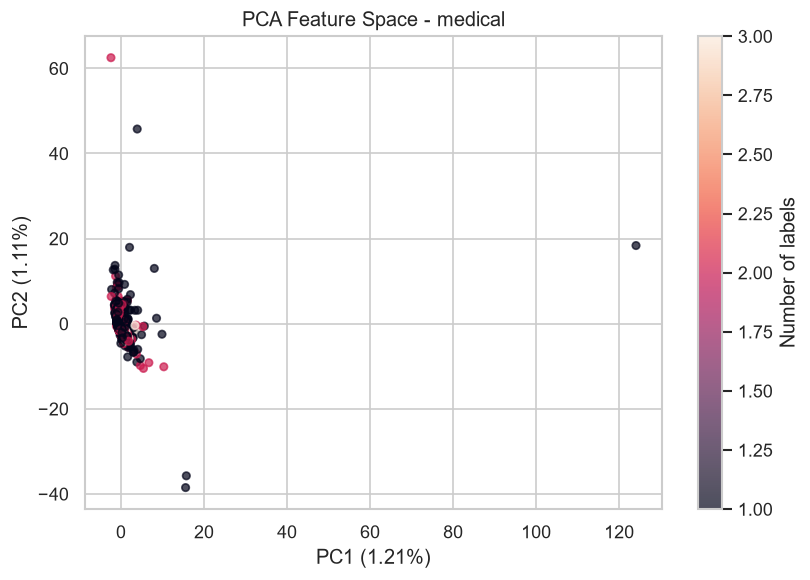

Saved: outputs\graphs\08_pca_feature_space_medical.pdf


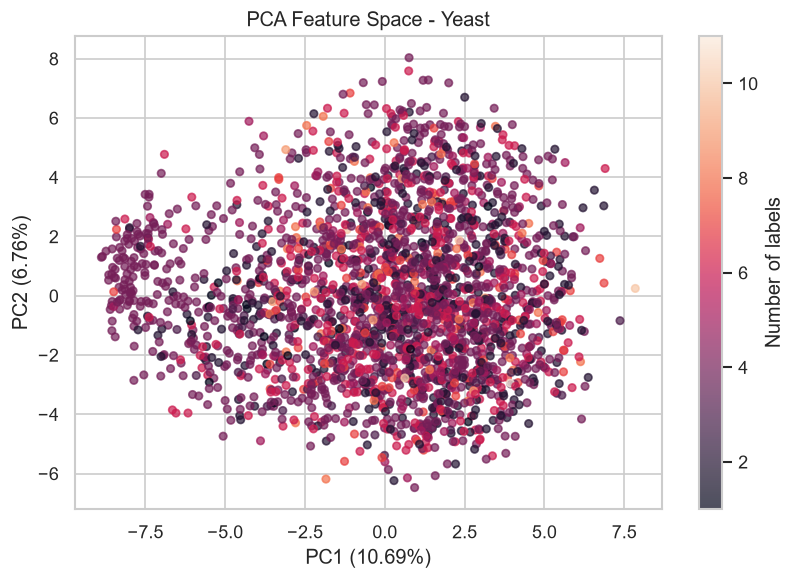

Saved: outputs\graphs\08_pca_feature_space_Yeast.pdf


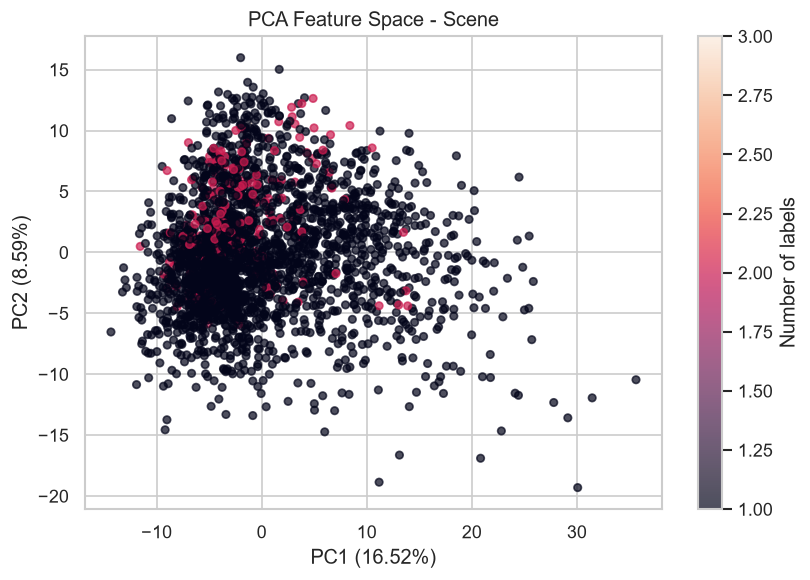

Saved: outputs\graphs\08_pca_feature_space_Scene.pdf


In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def plot_pca_feature_space(dataset_name, X, Y):
    X_num = X.apply(pd.to_numeric, errors="coerce").fillna(0)

    scaler = StandardScaler(with_mean=False if X_num.shape[1] > 1000 else True)
    X_scaled = scaler.fit_transform(X_num)

    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_scaled)

    plot_df = pd.DataFrame({
        "PC1": coords[:, 0],
        "PC2": coords[:, 1],
        "Number of Labels": Y.sum(axis=1)
    })

    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(
        plot_df["PC1"],
        plot_df["PC2"],
        c=plot_df["Number of Labels"],
        alpha=0.7,
        s=20
    )
    plt.colorbar(scatter, label="Number of labels")
    plt.title(f"PCA Feature Space - {dataset_name}")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
    savefig(f"08_pca_feature_space_{dataset_name}.pdf")

    return plot_df, pca


pca_results = {}

for name, obj in loaded.items():
    pca_df, pca_model = plot_pca_feature_space(name, obj["X"], obj["Y"])
    pca_results[name] = {"df": pca_df, "model": pca_model}


## 13. Thứ tự graph

1. Dataset Statistics.
2. Label Frequency Distribution.
3. Label Cardinality Distribution.
4. Label Density Comparison.
5. Label Correlation Heatmap.
6. Pairwise Association Matrix.
7. Top Pairwise Associations.
8. Label Co-occurrence Network.
9. PCA Feature Space.

